# 00 — Visión por Computador Clásica (antes de CNN)

Este notebook acompaña al documento teórico **00 — Introducción a la Visión por Computador Clásica**.

## Objetivos

1. Aplicar un **filtro clásico** (Sobel) para detectar bordes.
2. Entrenar una **CNN mínima** y visualizar:
   - **Filtros aprendidos** (kernels) de la primera capa convolucional.
   - **Mapas de activación** (feature maps).
3. Comparar intuitivamente **Sobel vs filtros aprendidos por CNN**.

> Nota: usaremos **Fashion-MNIST** por simplicidad.


## Siglas y descriptores (visión clásica)

En visión clásica se usaban *features* diseñadas a mano. Algunas siglas típicas:

- **HOG**: *Histogram of Oriented Gradients* — histogramas de **orientaciones de gradiente** por celdas.
- **SIFT**: *Scale-Invariant Feature Transform* — detecta puntos clave y describe parches, **invariante a escala**.
- **SURF**: *Speeded-Up Robust Features* — alternativa a SIFT optimizada para ser **más rápida**.
- **LBP**: *Local Binary Patterns* — describe **texturas** comparando píxeles con su vecindad.

También:

- **Histogramas de color**: resumen estadístico de intensidades (por canal) para describir una imagen.

> En Deep Learning (CNN), parte de este trabajo lo aprende el modelo automáticamente.


## 1) Imports y utilidades

Si estás en Colab: `Runtime → Change runtime type → GPU` (opcional).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Intentamos usar OpenCV si está disponible; si no, usamos un fallback con NumPy.
try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

print("OpenCV disponible:", HAS_CV2)


OpenCV disponible: True


## 2) Filtro clásico: Sobel (detección de bordes)

**Sobel** aproxima el gradiente de la imagen (cambios bruscos de intensidad). Es un ejemplo típico de visión clásica:

- No “entiende” objetos.
- Detecta cambios locales.

En CNN, los **primeros filtros aprendidos** suelen parecerse a detectores de bordes (no siempre, pero a menudo).


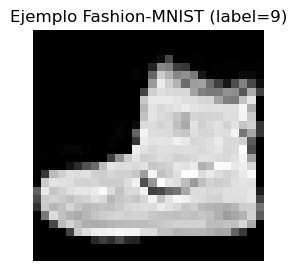

In [2]:
# Cargamos un ejemplo desde Fashion-MNIST (para no depender de archivos locales)
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

img = X_train[0]  # una imagen 28x28 en escala de grises
plt.figure(figsize=(3,3))
plt.imshow(img, cmap="gray")
plt.title(f"Ejemplo Fashion-MNIST (label={y_train[0]})")
plt.axis("off")
plt.show()


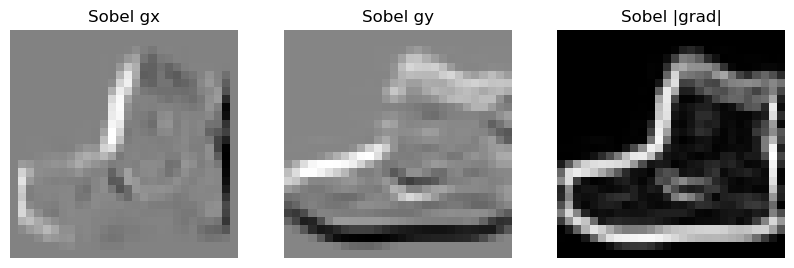

In [3]:
def sobel_edges(gray_img):
    # gray_img: 2D np.array
    if HAS_CV2:
        gx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
    else:
        # fallback NumPy: kernels Sobel básicos
        Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)
        Ky = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float64)

        def conv2d(a, k):
            kh, kw = k.shape
            pad_h, pad_w = kh//2, kw//2
            ap = np.pad(a, ((pad_h,pad_h),(pad_w,pad_w)), mode='edge')
            out = np.zeros_like(a, dtype=np.float64)
            for i in range(a.shape[0]):
                for j in range(a.shape[1]):
                    patch = ap[i:i+kh, j:j+kw]
                    out[i,j] = np.sum(patch * k)
            return out

        gx = conv2d(gray_img, Kx)
        gy = conv2d(gray_img, Ky)

    mag = np.sqrt(gx**2 + gy**2)
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-9)
    return gx, gy, mag

gx, gy, mag = sobel_edges(img)

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.imshow(gx, cmap='gray'); plt.title('Sobel gx'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(gy, cmap='gray'); plt.title('Sobel gy'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(mag, cmap='gray'); plt.title('Sobel |grad|'); plt.axis('off')
plt.show()


## 3) CNN mínima: entrenar y visualizar filtros aprendidos

Entrenaremos una CNN pequeña para clasificar Fashion-MNIST.

Luego veremos:

- **Kernels (filtros) aprendidos** en la primera capa Conv2D.
- **Mapas de activación**: qué “responde” cada filtro ante una imagen.

> Esto es el paralelismo con Sobel: Sobel es un filtro fijo; en CNN, los filtros se aprenden.


In [4]:
# Preparamos datos
X_train_n = X_train.astype('float32') / 255.0
X_test_n  = X_test.astype('float32') / 255.0

# Añadimos canal (28,28,1)
X_train_n = X_train_n[..., None]
X_test_n  = X_test_n[..., None]

num_classes = 10

# Modelo simple
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', name='conv1'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', name='conv2'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3


2026-03-05 19:56:34.989832: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.


422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.7656 - loss: 0.6580 - val_accuracy: 0.8333 - val_loss: 0.4527
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.8481 - loss: 0.4234 - val_accuracy: 0.8617 - val_loss: 0.3894
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.8639 - loss: 0.3782 - val_accuracy: 0.8675 - val_loss: 0.3727


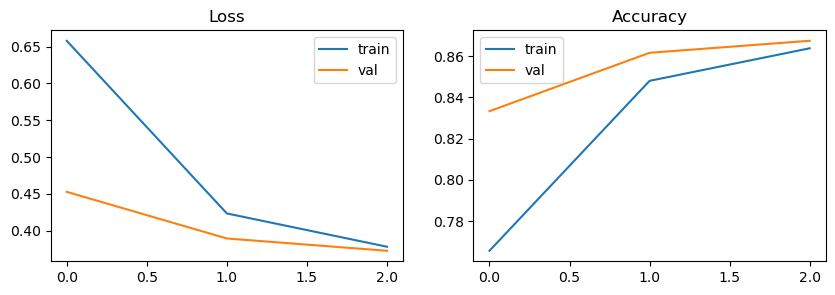

In [5]:
# Entrenamiento rápido (pocas épocas para clase)
history = model.fit(
    X_train_n, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=128,
    verbose=1
)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.show()


## 4) Visualización 1 — Filtros aprendidos (kernels) en la primera capa

La primera capa convolucional aprende **pequeños filtros 3×3**.

A menudo, tras pocas épocas, aparecen filtros tipo:
- detectores de borde
- detectores de diagonales
- realce de contrastes

No siempre será “igual que Sobel”, pero conceptualmente es el mismo tipo de operación: **convolución**.


kernels shape: (3, 3, 1, 16)


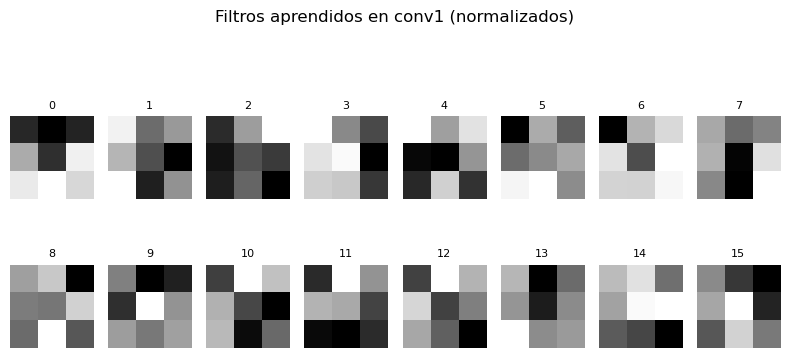

In [6]:
# Extraemos pesos de la primera capa
conv1 = model.get_layer('conv1')
kernels, biases = conv1.get_weights()
# kernels shape: (3,3,1,16)
print('kernels shape:', kernels.shape)

plt.figure(figsize=(8,4))
for i in range(kernels.shape[-1]):
    k = kernels[:,:,0,i]
    k_norm = (k - k.min()) / (k.max() - k.min() + 1e-9)
    plt.subplot(2,8,i+1)
    plt.imshow(k_norm, cmap='gray')
    plt.axis('off')
    plt.title(str(i), fontsize=8)
plt.suptitle('Filtros aprendidos en conv1 (normalizados)', y=1.02)
plt.tight_layout()
plt.show()


## 5) Visualización 2 — Mapas de activación (feature maps)

Un **feature map** muestra dónde “responde” un filtro en una imagen.

Comparación mental:
- Sobel produce un mapa de bordes.
- Cada filtro aprendido produce su propio “mapa de respuesta”.


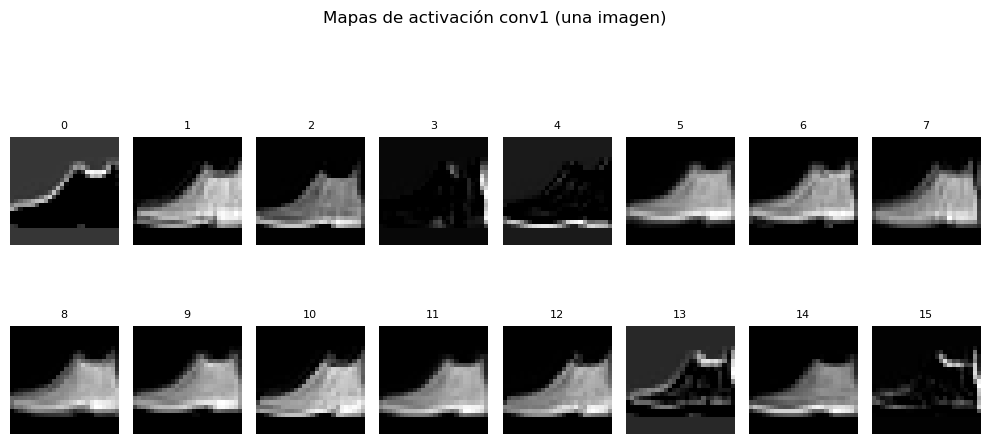

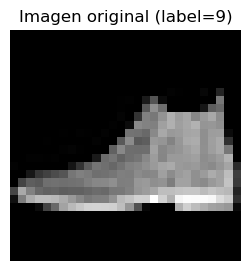

In [7]:
# Modelo auxiliar para obtener activaciones de conv1
# Fuerza a que el modelo quede "llamado" (build del grafo)
_ = model.predict(X_test_n[:1], verbose=0)

# Ahora ya existe model.inputs / model.input
activation_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer('conv1').output)

test_img = X_test_n[0:1]  # una imagen
acts = activation_model.predict(test_img, verbose=0)  # (1, 26, 26, 16)
acts = acts[0]

plt.figure(figsize=(10,5))
for i in range(16):
    a = acts[:,:,i]
    a_norm = (a - a.min()) / (a.max() - a.min() + 1e-9)
    plt.subplot(2,8,i+1)
    plt.imshow(a_norm, cmap='gray')
    plt.axis('off')
    plt.title(str(i), fontsize=8)
plt.suptitle('Mapas de activación conv1 (una imagen)', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(3,3))
plt.imshow(test_img[0,:,:,0], cmap='gray')
plt.title(f'Imagen original (label={y_test[0]})')
plt.axis('off')
plt.show()


## 6) Comparativa visual: Sobel vs activaciones de CNN

**Sobel** (clásico):
- filtro fijo
- detecta bordes según un criterio definido a mano

**CNN** (aprendido):
- filtros ajustados por backpropagation
- cada filtro puede especializarse en un patrón diferente

### Preguntas para el alumnado

1. ¿Qué filtros aprendidos “se parecen” más a un detector de bordes? (mira los kernels)
2. ¿En qué zonas de la imagen responde más un filtro “tipo borde”? (mira activaciones)
3. ¿Por qué crees que aparecen filtros parecidos a Sobel en la primera capa?


## 7) Para conectar con CNN (Capítulo 10)

- La convolución es una operación clásica (Sobel, Gaussian, etc.).
- Una CNN **aprende** sus propios filtros.
- La primera capa suele aprender patrones simples; capas profundas combinan esos patrones.

En el próximo notebook (CNN formal) trabajaremos ya con:
- arquitectura CNN más estable
- regularización
- comparación de profundidad
